In [30]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split 
from torch import nn
import torch
import random

In [31]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

out = np.load('training-val-test-data.npz')
th_train = out['th'] #th[0],th[1],th[2],th[3],...
u_train = out['u'] #u[0],u[1],u[2],u[3],...

# data = np.load('test-prediction-submission-file.npz')
data = np.load('hidden-test-simulation-submission-file.npz')
upast_test = data['u'] #N by u[k-15],u[k-14],...,u[k-1]
thpast_test = data['th'] #N by y[k-15],y[k-14],...,y[k-1]
# thpred = data['thnow'] #all zeros

In [32]:
def create_IO_data(u,y,na,nb):
    X = []
    Y = []
    for k in range(max(na,nb), len(y)):
        u_past = u[k-nb:k]
        y_past = y[k-na:k]

        # Trigonometric features of the raw angles
        sin_y = np.sin(y_past)
        cos_y = np.cos(y_past)
        
        X.append(np.concatenate([u_past,sin_y, cos_y]))
        Y.append(y[k])
    return np.array(X), np.array(Y)

In [33]:
na = 15
nb = 15
u_tr, u_val, th_tr, th_val = train_test_split(u_train, th_train, shuffle = False)

Xtrain_u, Ytrain_u = create_IO_data(u_tr, th_tr, na, nb)
Xval_u, Yval_u = create_IO_data(u_val, th_val, na, nb)

# Scaling of variables
X_mean = np.mean(Xtrain_u, axis = 0)
X_std = np.std(Xtrain_u, axis = 0)

Y_mean = float(np.mean(Ytrain_u))
Y_std = float(np.std(Ytrain_u))

Xtrain = (Xtrain_u - X_mean)/X_std
Xval = (Xval_u - X_mean)/X_std

Ytrain = (Ytrain_u - Y_mean)/Y_std
Yval = (Yval_u - Y_mean)/Y_std

In [34]:
def simulation_IO_model(f, ulist, ylist, skip=50):
    upast = ulist[skip-nb:skip].tolist()
    ypast = ylist[skip-na:skip].tolist()
    Y = ylist[:skip].tolist()
    for u in ulist[skip:]:
        x = np.concatenate([upast, np.sin(ypast), np.cos(ypast)]).astype(float)
        ypred = f(x)
        Y.append(float(ypred))
        upast.append(u)
        upast.pop(0)
        ypast.append(ypred)
        ypast.pop(0)
    return np.array(Y)

In [35]:
class Network(nn.Module): 
    def __init__(self, n_in, n_hidden_nodes): 
        super(Network,self).__init__()
        self.lay1 = nn.Linear(n_in, n_hidden_nodes).double()
        self.lay2 = nn.Linear(n_hidden_nodes, n_hidden_nodes).double()
        self.lay3 = nn.Linear(n_hidden_nodes, n_hidden_nodes).double()
        self.lay4 = nn.Linear(n_hidden_nodes, n_hidden_nodes).double()
        self.lay5 = nn.Linear(n_hidden_nodes, 1).double()

    def forward(self,u): 
        # u.shape == (N,10)
        #u = u[:, None]  # Convert u from shape (N,) to (N,1)
        x1 = torch.nn.functional.elu(self.lay1(u)) 
        x2 = torch.nn.functional.elu(self.lay2(x1))
        x3 = torch.nn.functional.elu(self.lay3(x2))
        x4 = torch.nn.functional.elu(self.lay4(x3))
        y = self.lay5(x4)[:, 0] 

        return y

n_hidden_nodes = 64
epochs = 5000 

In [36]:
model = Network(Xtrain.shape[1],n_hidden_nodes) #create the network
    
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3, weight_decay = 1e-5)

Xtrain,Ytrain, Xval, Yval = [torch.as_tensor(x) for x in [Xtrain,Ytrain, Xval, Yval]]

best_val_loss = float('inf')
best_weights = None

for epoch in range(epochs):
    Loss = torch.mean((model(Xtrain)-Ytrain)**2)
    optimizer.zero_grad() #set the gradient buffers to zero, this is essential.
    Loss.backward()
    optimizer.step()
    
    if epoch%100==0: 
        model.eval()
        with torch.no_grad():
            val_loss = torch.mean((model(Xval) - Yval)**2).item()**0.5
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = model.state_dict()
        
        print(epoch,Loss.item()**0.5)

# Restore the absolute best parameter state found during validation tracking
model.load_state_dict(best_weights)
model.eval()

skip = max(na,nb)
th_train_sim = simulation_IO_model(lambda x: (model(torch.as_tensor((x - X_mean) / X_std).unsqueeze(0).double()).item() * Y_std) + Y_mean, u_train, th_train, skip=skip)
print('train simulation errors:')
print('RMS:', np.mean((th_train_sim[skip:]-th_train[skip:])**2)**0.5,'radians')
print('RMS:', np.mean((th_train_sim[skip:]-th_train[skip:])**2)**0.5/(2*np.pi)*360,'degrees')
print('NRMS:', np.mean((th_train_sim[skip:]-th_train[skip:])**2)**0.5/th_train.std()*100,'%')


skip = 50
def model_f(x):
    x_t = torch.as_tensor((x - X_mean) / X_std).double().view(1, -1)
    y = model(x_t).detach().cpu().numpy().squeeze()
    return float(y * Y_std + Y_mean)

th_test_sim = simulation_IO_model(model_f, upast_test, thpast_test, skip=50)

assert len(th_test_sim) == len(thpast_test)   
np.savez('hidden-test-simulation-example-submission-file.npz',
         th=th_test_sim,                        
         u=upast_test)

0 0.9819414668419509
100 0.070717781993281
200 0.044833732277458516
300 0.034470789499573634
400 0.02868088125357703
500 0.02462369366496699
600 0.02153118707075766
700 0.019128688431690487
800 0.017250378610761962
900 0.015779978583459114
1000 0.014633253937843248
1100 0.013727323274476342
1200 0.013043356155979263
1300 0.012441714520550777
1400 0.011987618781545643
1500 0.011766592288183352
1600 0.011212855679479357
1700 0.010851046953791093
1800 0.010639508783904248
1900 0.010322140524432994
2000 0.011497311549290767
2100 0.009938649612818137
2200 0.009676722265731269
2300 0.013030636307314707
2400 0.009458732042130434
2500 0.009219522284983022
2600 0.009013509442326487
2700 0.009374061411778064
2800 0.008948873939790396
2900 0.00873843738643098
3000 0.008562040763796531
3100 0.00849256821281423
3200 0.008817152265138076
3300 0.008409366664477464
3400 0.008244087775302361
3500 0.05471600247718692
3600 0.008389471480816616
3700 0.008152088463953601
3800 0.007997437063032412
3900 0.01

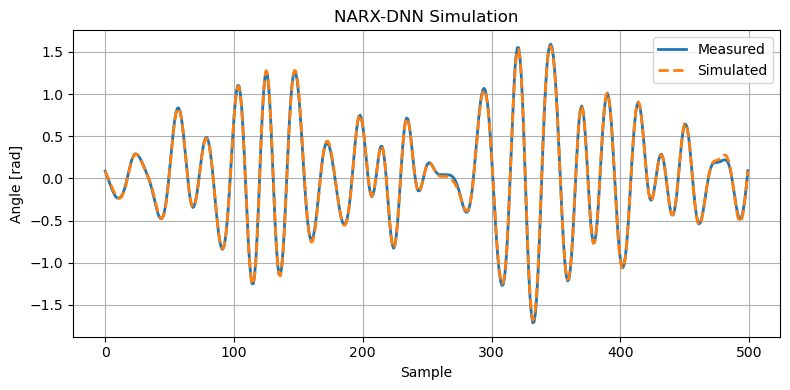

In [37]:
plt.figure(figsize=(8,4))

start = 1000
end = 1500

plt.plot(th_train[start:end], linewidth=2, label='Measured')
plt.plot(th_train_sim[start:end], '--', linewidth=2, label='Simulated')

plt.xlabel('Sample')
plt.ylabel('Angle [rad]')
plt.title('NARX-DNN Simulation')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('ANN_simulation_fit.png', dpi=300, bbox_inches='tight')
plt.show()

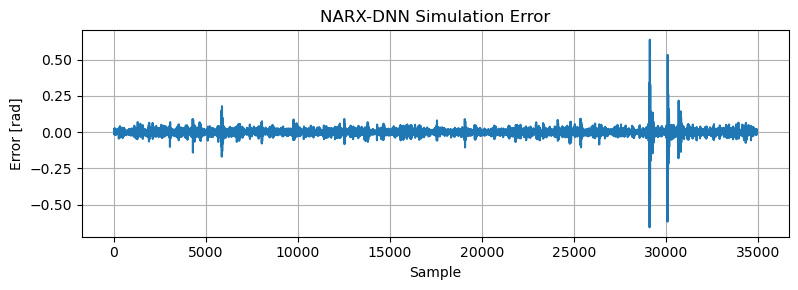

In [38]:
error = th_train_sim[skip:] - th_train[skip:]

plt.figure(figsize=(8,3))

plt.plot(error)

plt.xlabel('Sample')
plt.ylabel('Error [rad]')
plt.title('NARX-DNN Simulation Error')
plt.grid(True)

plt.tight_layout()
plt.savefig('ANN_simulation_error.png', dpi=300, bbox_inches='tight')
plt.show()

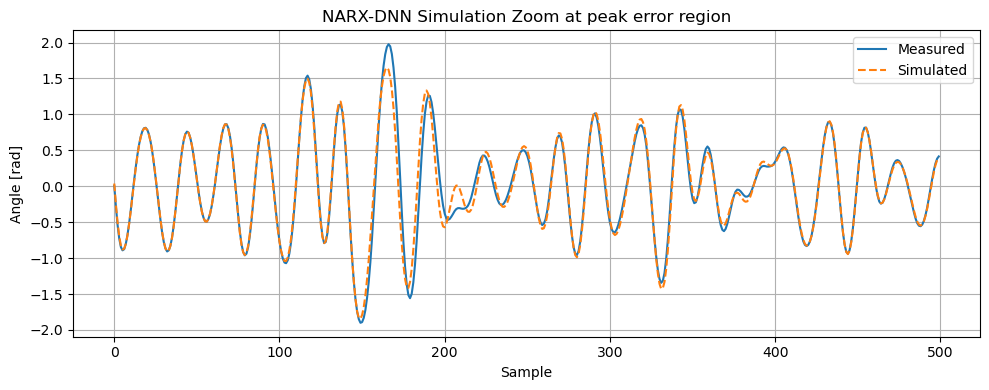

In [39]:
start = 29000
end = 29500

plt.figure(figsize=(10,4))
plt.plot(th_train[start:end], label='Measured')
plt.plot(th_train_sim[start:end], '--', label='Simulated')
plt.xlabel('Sample')
plt.ylabel('Angle [rad]')
plt.title('NARX-DNN Simulation Zoom at peak error region')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('ANN_simulation_zoom.png', dpi=300, bbox_inches='tight')
plt.show()